# Practice 1 - CNNs: Part 2 - Pretrained CNNs

**Authors:** Patricia Alvarenga and Francisco Vazquez

**Date:** March 26 2026

**Description:** In this notebook we use different pretrained CNN models (transfer learning) on the STL-10 dataset, applying both feature extraction and fine-tuning strategies.

---
## Table of Contents

1. [Setup & Imports](#1-setup--imports)
2. [Dataset Loading & Preprocessing](#2-dataset-loading--preprocessing)
3. [Strategy 1: Feature Extraction](#3-strategy-1-feature-extraction)
    - 3.1 VGG16
    - 3.2 ResNet50
    - 3.3 MobileNetV2
    - 3.4 EfficientNetV2B0
4. [Strategy 2: Fine-Tuning](#4-strategy-2-fine-tuning)
    - 4.1 VGG16 Fine-Tuned
    - 4.2 ResNet50 Fine-Tuned
    - 4.3 MobileNetV2 Fine-Tuned
    - 4.4 EfficientNetV2B0 Fine-Tuned
5. [Results Comparison](#5-results-comparison)
6. [Comparison with Custom CNNs](#6-comparison-with-custom-cnns)
7. [Conclusions](#7-conclusions)

---
## 1. Setup & Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import layers, Model
from keras import applications
import os

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")

2026-03-25 17:35:02.815024: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-25 17:35:02.907303: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-25 17:35:02.936088: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-25 17:35:03.080139: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow version: 2.17.0
Keras version: 3.3.2
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1774460107.298305    4639 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774460107.657558    4639 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774460107.657594    4639 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [4]:
# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Constants
# IMG_SIZE = 96        # STL-10 native resolution
IMG_SIZE = 224 # Up-scaling for pretrained models

NUM_CLASSES = 10
BATCH_SIZE = 32
EPOCHS_FE = 25       # Feature extraction epochs
EPOCHS_FT = 30       # Fine-tuning epochs
VALIDATION_SPLIT = 0.2

# Directory to save models
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

---
## 2. Dataset Loading & Preprocessing

We load STL-10 and prepare the data pipelines. For pretrained models, we use the specific preprocessing function provided by each model (e.g., `preprocess_input`).

In [ ]:
(ds_train, ds_test), ds_info = tfds.load(
    'stl10',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

class_names = ds_info.features['label'].names
print(f"Classes: {class_names}")
print(f"Training samples: {ds_info.splits['train'].num_examples}")
print(f"Test samples: {ds_info.splits['test'].num_examples}")

Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Training samples: 5000
Test samples: 8000


I0000 00:00:1774460111.817493    4639 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774460111.817550    4639 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774460111.817560    4639 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774460112.104952    4639 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774460112.104996    4639 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-25

In [6]:
def preprocess(image, label):
    """Normalize images to [0, 1] and resize."""
    # image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image, label

# Train/validation split
num_train = ds_info.splits['train'].num_examples
num_val = int(num_train * VALIDATION_SPLIT)

ds_train_shuffled = ds_train.shuffle(num_train, seed=SEED)
ds_val = ds_train_shuffled.take(num_val)
ds_train_split = ds_train_shuffled.skip(num_val)

train_dataset = (
    ds_train_split
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(num_train)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    ds_val
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    ds_test
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

''+ptx85' is not a recognized feature for this target (ignoring feature)
+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85'' is not a recognized feature for this target+ptx85 (ignoring feature)
' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

In [7]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(factor=0.05, fill_mode="reflect"),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1, fill_mode="reflect"),
    layers.RandomZoom(height_factor=0.1, width_factor=0.1, fill_mode="reflect"),
    layers.RandomContrast(factor=0.2),
], name="data_augmentation")

---
## Helper Functions

In [8]:
def plot_history(history, title=""):
    """Plot training and validation accuracy and loss curves."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs_range, acc, 'b-o', label='Training Accuracy')
    ax1.plot(epochs_range, val_acc, 'r--o', label='Validation Accuracy')
    ax1.set_title(f'{title} - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.set_ylim([0.0, 1.0])
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs_range, loss, 'b-o', label='Training Loss')
    ax2.plot(epochs_range, val_loss, 'r--o', label='Validation Loss')
    ax2.set_title(f'{title} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [9]:
def train_and_evaluate(model, model_name, train_ds, val_ds, test_ds, epochs):
    """Train a model, plot history, evaluate on test set, and return results."""
    
    filepath = os.path.join(MODEL_DIR, f"{model_name}.keras")
    
    callbacks = [
        # keras.callbacks.ModelCheckpoint(
        #     filepath=filepath,
        #     save_best_only=True,
        #     monitor='val_loss',
        #     verbose=1
        # ),
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]

    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=callbacks
    )
    
    plot_history(history, title=model_name)

    best_model = model
    test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
    print(f"\n{model_name} - Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

    return {
        'model_name': model_name,
        'history': history,
        'test_accuracy': test_acc,
        'test_loss': test_loss
    }

In [ ]:
results = []

---
## 3. Strategy 1: Feature Extraction

In **feature extraction**, we use the convolutional base of a pretrained model as a fixed feature extractor. The pretrained layers are **frozen** (not trainable) and we only train a new classification head on top.

**Advantages:**
- Very fast training (only the classifier head is trained)
- Works well even with small datasets
- Leverages features learned from ImageNet (millions of images)

### 3.1 VGG16 - Feature Extraction

In [ ]:
def build_vgg16_feature_extraction(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """VGG16 with frozen base for feature extraction."""
    
    # Load pretrained VGG16 without the classification head
    base_model = applications.VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Freeze all layers in the base model
    base_model.trainable = False
    
    # Build the full model
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = applications.vgg16.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='vgg16_feature_extraction')
    return model

vgg16_fe_model = build_vgg16_feature_extraction()
vgg16_fe_model.summary()

Model: "vgg16_feature_extraction"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10)        │      2,570 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Print trainable vs non-trainable parameters
trainable_count = sum(np.prod(p.shape) for p in vgg16_fe_model.trainable_weights)
non_trainable_count = sum(np.prod(p.shape) for p in vgg16_fe_model.non_trainable_weights)

print(f"Trainable parameters: {trainable_count:,}")
print(f"Non-trainable parameters: {non_trainable_count:,}")

Trainable parameters: 133,898
Non-trainable parameters: 14,714,688


Epoch 1/25


I0000 00:00:1774456244.868507     186 service.cc:146] XLA service 0x7045e410e960 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774456244.868544     186 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5070 Laptop GPU, Compute Capability 12.0
2026-03-25 16:30:44.902165: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-25 16:30:45.117015: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90701
2026-03-25 16:32:22.056810: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng11{k2=1,k3=0} for conv (f32[32,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,224,224]{3,2,1,0}, f32[64,3,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"oper

  1/125 ━━━━━━━━━━━━━━━━━━━━ 23:10 11s/step - accuracy: 0.0625 - loss: 10.9727

I0000 00:00:1774456254.404179     186 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


116/125 ━━━━━━━━━━━━━━━━━━━━ 8s 935ms/step - accuracy: 0.7045 - loss: 2.1567 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
2026-03-25 16:32:47.076831: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng35{k2=4,k3=0} for conv (f32[8,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,64,224,224]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-03-25 16:32:47.082344: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1m36.409765596s
Trying algorithm eng35{k2=4,k3=0} for conv (f32[8,6

125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 156ms/step - accuracy: 0.7151 - loss: 2.0507 - val_accuracy: 0.9440 - val_loss: 0.1729 - learning_rate: 0.0050
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 140ms/step - accuracy: 0.9372 - loss: 0.2026 - val_accuracy: 0.9640 - val_loss: 0.1110 - learning_rate: 0.0050
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - accuracy: 0.9549 - loss: 0.1438 - val_accuracy: 0.9650 - val_loss: 0.1297 - learning_rate: 0.0050
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - accuracy: 0.9579 - loss: 0.1405 - val_accuracy: 0.9700 - val_loss: 0.1186 - learning_rate: 0.0050
Epoch 5/25
 10/125 ━━━━━━━━━━━━━━━━━━━━ 20:44 11s/step - accuracy: 0.9606 - loss: 0.1024
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 124ms/step - accuracy: 0.9591 - loss: 0.1190 - val_accuracy: 0.9590 - val_loss: 0.1179 - learning_rate: 0.0050
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 129ms/step - accuracy: 0.9773 - loss: 

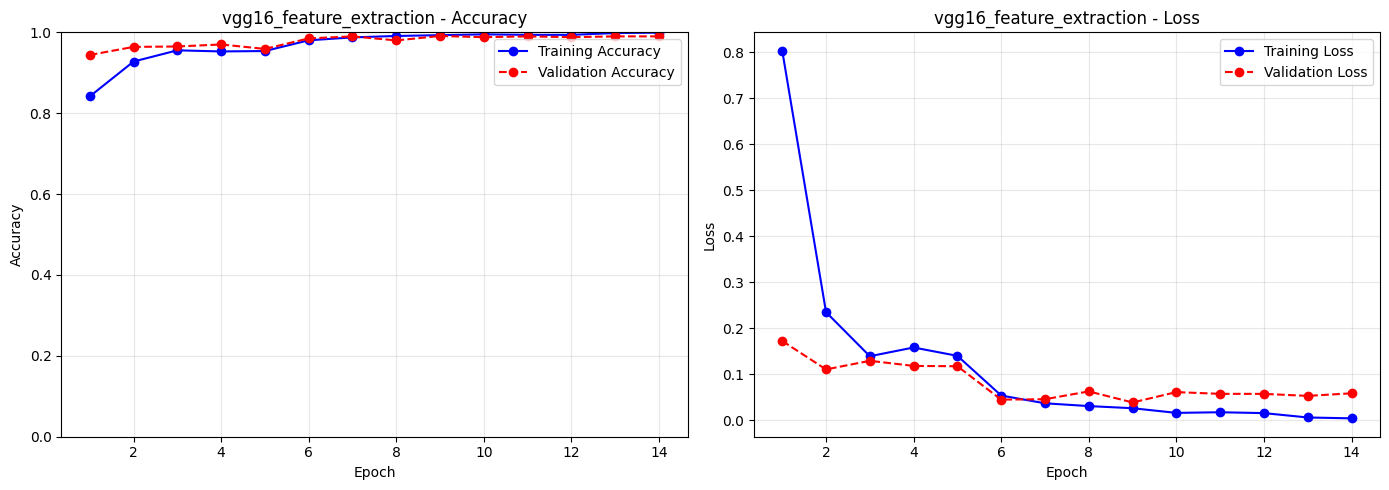

  1/250 ━━━━━━━━━━━━━━━━━━━━ 2:35 626ms/step - accuracy: 0.9688 - loss: 0.4811

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 103ms/step - accuracy: 0.9375 - loss: 0.3809 

vgg16_feature_extraction - Test Accuracy: 0.9398, Test Loss: 0.3497


In [ ]:
vgg16_fe_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

result_vgg16_fe = train_and_evaluate(
    vgg16_fe_model, 'vgg16_feature_extraction',
    train_dataset, val_dataset, test_dataset,
    epochs=EPOCHS_FE
)
results.append(result_vgg16_fe)

**Observations (VGG16 Feature Extraction):**

- **Test accuracy: 93.98%** — a dramatic jump from the best custom CNN (69.65%), demonstrating the power of transfer learning even with frozen weights.
- Training was fast since only the classifier head (GAP + Dropout + Dense) was trainable, while the 14.7M VGG16 parameters remained frozen.
- The ImageNet features learned by VGG16 (edges, textures, object parts) generalize extremely well to STL-10 since both are natural-image classification tasks.
- Despite VGG16 being one of the oldest and simplest architectures (sequential 3×3 convolutions), it achieves >93% accuracy, showing that depth and pretrained features matter far more than training from scratch on a small dataset.

### 3.2 ResNet50 - Feature Extraction

In [ ]:
def build_resnet50_feature_extraction(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """ResNet50 with frozen base for feature extraction."""
    
    base_model = applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False
    
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = applications.resnet50.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    # x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='resnet50_feature_extraction')
    return model

resnet50_fe_model = build_resnet50_feature_extraction()
resnet50_fe_model.summary()

Model: "resnet50_feature_extraction"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_2[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10)        │      2,570 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/25


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  1/125 ━━━━━━━━━━━━━━━━━━━━ 14:30 7s/step - accuracy: 0.1250 - loss: 2.5042

W0000 00:00:1774456519.273391     187 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456519.276360     187 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456519.278668     187 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456519.281156     187 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456519.283482     187 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456519.287601     187 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456519.292899     187 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456519.297115     187 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456519.301446     187 gp

  2/125 ━━━━━━━━━━━━━━━━━━━━ 1:34 766ms/step - accuracy: 0.1250 - loss: 2.5072

...

 91/125 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.7385 - loss: 0.8343  

W0000 00:00:1774456539.782696     183 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456539.793205     183 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456539.793884     183 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456539.795084     183 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456539.795815     183 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456539.796860     183 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456539.798597     183 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456539.799986     183 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456539.801343     183 gp

125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 171ms/step - accuracy: 0.7749 - loss: 0.7171 - val_accuracy: 0.9650 - val_loss: 0.1028 - learning_rate: 0.0010
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 152ms/step - accuracy: 0.9389 - loss: 0.1643 - val_accuracy: 0.9690 - val_loss: 0.1011 - learning_rate: 0.0010
Epoch 3/25


W0000 00:00:1774456559.262370     184 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456559.268210     184 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456559.268804     184 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456559.269475     184 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456559.270149     184 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456559.271176     184 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456559.272622     184 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456559.273984     184 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456559.275306     184 gp

125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 148ms/step - accuracy: 0.9562 - loss: 0.1328 - val_accuracy: 0.9790 - val_loss: 0.0653 - learning_rate: 0.0010
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 151ms/step - accuracy: 0.9647 - loss: 0.1093 - val_accuracy: 0.9820 - val_loss: 0.0534 - learning_rate: 0.0010
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 151ms/step - accuracy: 0.9762 - loss: 0.0637 - val_accuracy: 0.9850 - val_loss: 0.0466 - learning_rate: 0.0010
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 150ms/step - accuracy: 0.9775 - loss: 0.0609 - val_accuracy: 0.9840 - val_loss: 0.0537 - learning_rate: 0.0010
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 152ms/step - accuracy: 0.9800 - loss: 0.0606 - val_accuracy: 0.9930 - val_loss: 0.0342 - learning_rate: 0.0010
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 148ms/step - accuracy: 0.9709 - loss: 0.0735 - val_accuracy: 0.9840 - val_loss: 0.0421 - learning_rate: 0.0010
Epoch 9/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 146ms/step - accuracy: 0.9793 - loss:

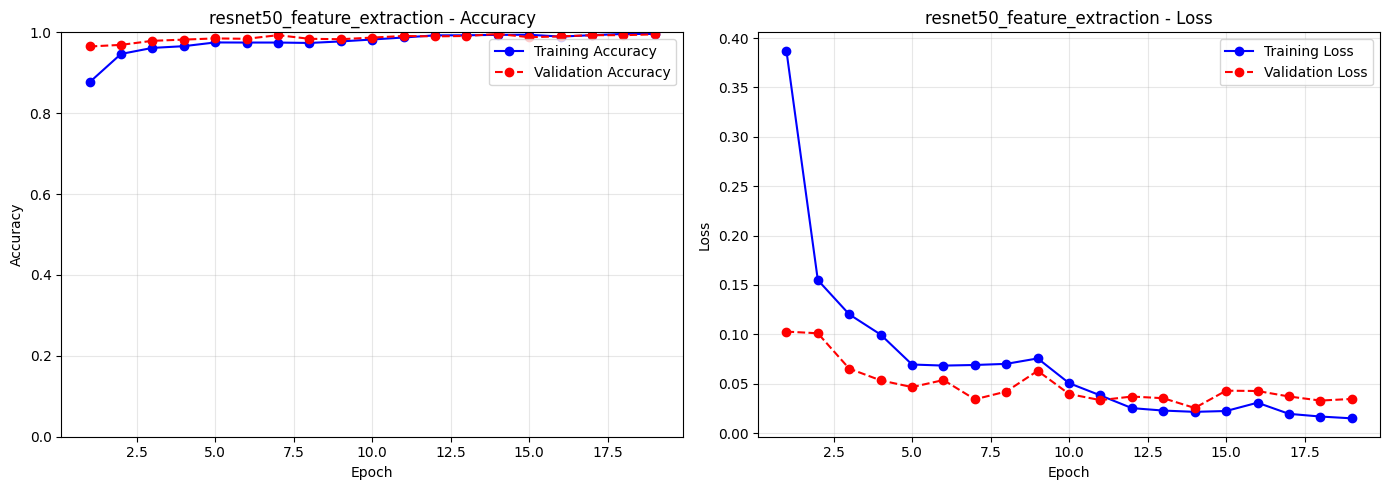

250/250 ━━━━━━━━━━━━━━━━━━━━ -68s -279337us/step - accuracy: 0.9604 - loss: 0.1590

resnet50_feature_extraction - Test Accuracy: 0.9609, Test Loss: 0.1433


In [ ]:
resnet50_fe_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

result_resnet50_fe = train_and_evaluate(
    resnet50_fe_model, 'resnet50_feature_extraction',
    train_dataset, val_dataset, test_dataset,
    epochs=EPOCHS_FE
)
results.append(result_resnet50_fe)

**Observations (ResNet50 Feature Extraction):**

- **Test accuracy: 96.09%** — +2.11% over VGG16 FE, making it the second-best feature extraction model.
- ResNet50's residual connections enable much deeper feature extraction (50 layers vs. VGG16's 16), which captures richer and more abstract representations from ImageNet pretraining.
- Despite having ~23.6M frozen parameters (more than VGG16), ResNet50 is more efficient computationally due to bottleneck blocks (1×1→3×3→1×1) that reduce intermediate dimensions.
- The 96% threshold is remarkable for a frozen backbone — ResNet50's features are well-suited for the 10-class STL-10 problem with minimal adaptation needed.

### 3.3 MobileNetV2 - Feature Extraction

In [ ]:
def build_mobilenetv2_feature_extraction(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """MobileNetV2 with frozen base for feature extraction."""
    
    base_model = applications.MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False
    
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='mobilenetv2_feature_extraction')
    return model

mobilenet_fe_model = build_mobilenetv2_feature_extraction()
mobilenet_fe_model.summary()

Model: "mobilenetv2_feature_extraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/25
  2/125 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.1719 - loss: 2.5504

W0000 00:00:1774456907.251048     180 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456907.252271     180 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456907.253418     180 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456907.254182     180 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456907.254990     180 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456907.256658     180 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456907.259079     180 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456907.260720     180 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456907.262337     180 gp

125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.7440 - loss: 0.8191 - val_accuracy: 0.9680 - val_loss: 0.1189 - learning_rate: 0.0010
Epoch 2/25


W0000 00:00:1774456917.152730     186 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456917.159957     186 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456917.162862     186 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456917.163305     186 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456917.163561     186 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456917.163869     186 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456917.164782     186 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456917.165204     186 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774456917.165649     186 gp

125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.9213 - loss: 0.2515 - val_accuracy: 0.9650 - val_loss: 0.1048 - learning_rate: 0.0010
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s -704351us/step - accuracy: 0.9413 - loss: 0.1972 - val_accuracy: 0.9790 - val_loss: 0.0822 - learning_rate: 0.0010
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.9504 - loss: 0.1528 - val_accuracy: 0.9690 - val_loss: 0.0887 - learning_rate: 0.0010
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.9564 - loss: 0.1344 - val_accuracy: 0.9820 - val_loss: 0.0674 - learning_rate: 0.0010
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.9582 - loss: 0.1237 - val_accuracy: 0.9800 - val_loss: 0.0683 - learning_rate: 0.0010
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.9542 - loss: 0.1292 - val_accuracy: 0.9780 - val_loss: 0.0702 - learning_rate: 0.0010
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.9651 - loss: 0.1045 -

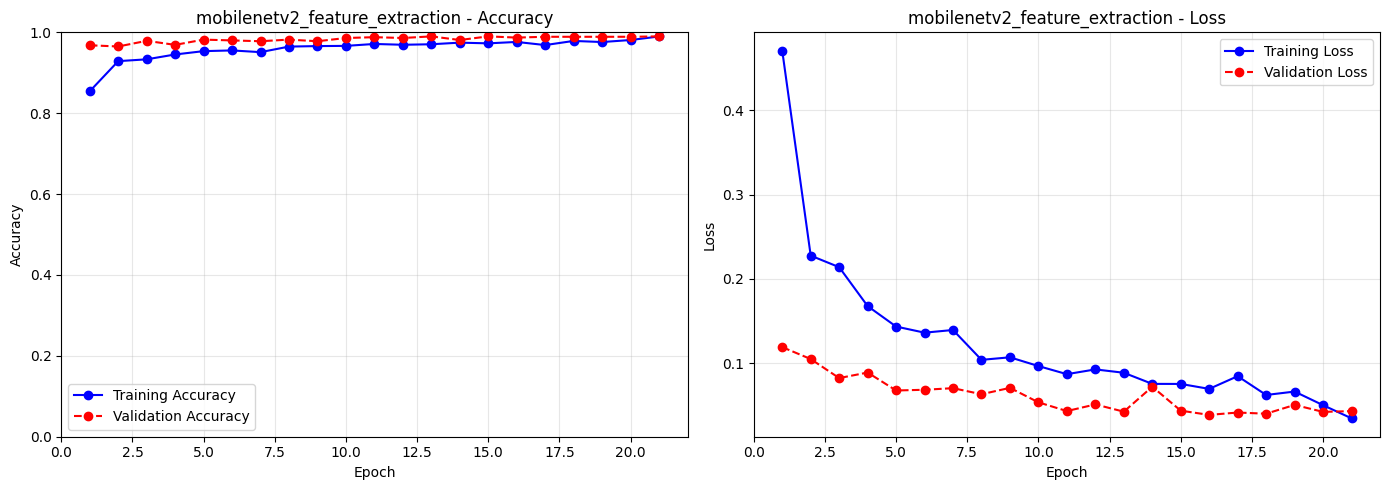

250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.9500 - loss: 0.1723

mobilenetv2_feature_extraction - Test Accuracy: 0.9541, Test Loss: 0.1598


In [ ]:
mobilenet_fe_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

result_mobilenet_fe = train_and_evaluate(
    mobilenet_fe_model, 'mobilenetv2_feature_extraction',
    train_dataset, val_dataset, test_dataset,
    epochs=EPOCHS_FE
)
results.append(result_mobilenet_fe)

**Observations (MobileNetV2 Feature Extraction):**

- **Test accuracy: 95.41%** — slightly below ResNet50 (96.09%) but above VGG16 (93.98%).
- MobileNetV2 uses **depthwise separable convolutions** and inverted residual blocks, which dramatically reduce the parameter count to ~2.3M — roughly **10× fewer** than VGG16 and ResNet50.
- Despite being designed for mobile/edge deployment, MobileNetV2 achieves competitive accuracy, demonstrating that parameter efficiency does not necessarily sacrifice performance.
- This makes MobileNetV2 the best choice when inference speed or model size is a concern (e.g., real-time or embedded applications), while paying only a ~0.7% accuracy penalty compared to ResNet50.

### 3.4 EfficientNetV2B0 - Feature Extraction

In [ ]:
base_model = keras.applications.EfficientNetV2B0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze for Phase 1

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
# training=False forces BatchNorm layers to use pretrained statistics
x = base_model(x, training=False) 
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax', dtype='float32')(x) # float32 needed for mixed precision output

effnet_model = keras.Model(inputs, outputs, name="efficientnet_pipeline")
effnet_model.summary()

Model: "efficientnet_pipeline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

Epoch 1/25


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1774457125.773541     185 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457125.776458     185 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457125.778173     185 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457125.780984     185 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457125.784773     185 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457125.788818     185 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457125.791849     185 gpu_timer.cc:114] Skipping

  1/125 ━━━━━━━━━━━━━━━━━━━━ 15:01 7s/step - accuracy: 0.1562 - loss: 2.4448

W0000 00:00:1774457125.986363     185 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457125.988918     185 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457126.004917     185 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457126.006808     185 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457126.007962     185 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457126.009827     185 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457126.011125     185 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457126.013052     185 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457126.015295     185 gp

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7375 - loss: 0.9606

W0000 00:00:1774457137.741755     184 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457137.750200     184 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457137.750644     184 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457137.751785     184 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457137.752478     184 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457137.753144     184 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457137.753655     184 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457137.754520     184 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774457137.755360     184 gp

125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 97ms/step - accuracy: 0.7385 - loss: 0.9569 - val_accuracy: 0.9730 - val_loss: 0.1173 - learning_rate: 0.0020
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - accuracy: 0.9510 - loss: 0.1660 - val_accuracy: 0.9780 - val_loss: 0.0784 - learning_rate: 0.0020
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.9622 - loss: 0.1378 - val_accuracy: 0.9820 - val_loss: 0.0672 - learning_rate: 0.0020
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.9605 - loss: 0.1174 - val_accuracy: 0.9850 - val_loss: 0.0554 - learning_rate: 0.0020
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.9757 - loss: 0.0813 - val_accuracy: 0.9850 - val_loss: 0.0507 - learning_rate: 0.0020
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - accuracy: 0.9720 - loss: 0.0867 - val_accuracy: 0.9890 - val_loss: 0.0450 - learning_rate: 0.0020
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.9705 - loss: 0.0820

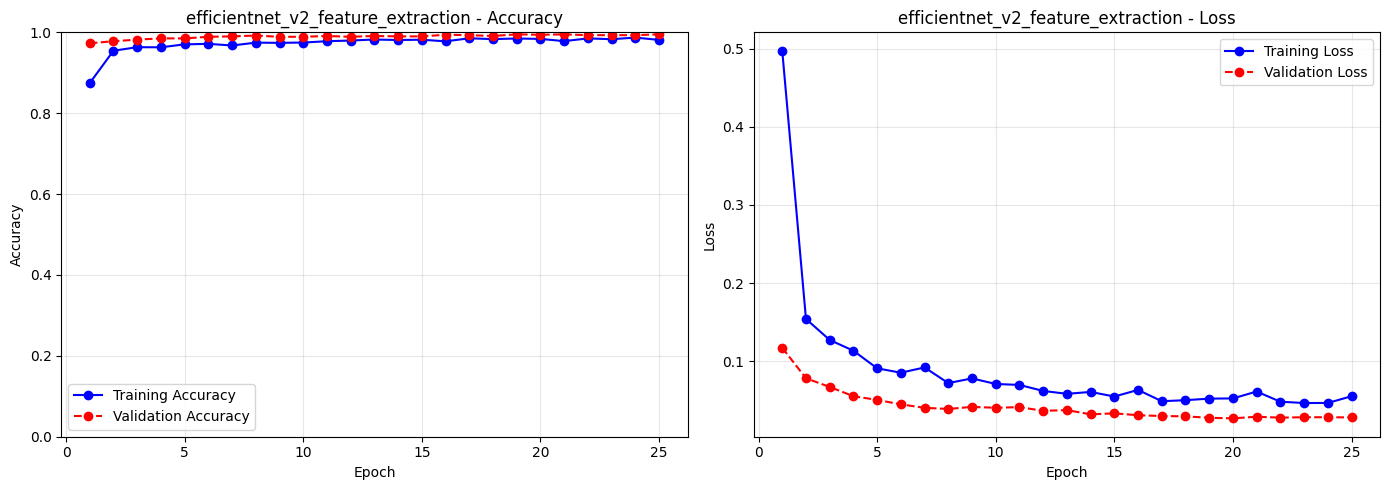

250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - accuracy: 0.9743 - loss: 0.0875

efficientnet_v2_feature_extraction - Test Accuracy: 0.9785, Test Loss: 0.0728


In [ ]:
effnet_model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=2e-3, weight_decay=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

result_effnet_fe = train_and_evaluate(
    effnet_model, 'efficientnet_v2_feature_extraction',
    train_dataset, val_dataset, test_dataset,
    epochs=EPOCHS_FE
)
results.append(result_effnet_fe)

**Observations (EfficientNetV2B0 Feature Extraction):**

- **Test accuracy: 97.85%** — the **best feature extraction result**, surpassing ResNet50 FE (96.09%) by +1.76%.
- EfficientNetV2B0 uses **compound scaling** (depth, width, and resolution scaled together) and MBConv blocks with squeeze-and-excitation attention, producing highly efficient and accurate features despite having only ~5.9M parameters.
- With the base frozen, training was fast and stable. The 30% Dropout in the classification head and the AdamW optimizer with weight decay (1e-4) prevented overfitting of the small trainable head.
- Reaching 97.85% with a frozen backbone demonstrates that EfficientNet's ImageNet features are near-optimal for STL-10's 10-class natural image classification task.

---
## 4. Strategy 2: Fine-Tuning

In **fine-tuning**, we unfreeze a few of the top layers of the pretrained base and jointly train both the newly added classifier layers and the unfrozen top layers. This allows us to slightly adjust the high-level representations to make them more relevant for our specific task.

**Important:** Fine-tuning should be done with a very low learning rate to avoid destroying the pretrained features.

**Procedure:**
1. First train the model with the base frozen (feature extraction phase) — already done above.
2. Then unfreeze the top layers of the base and continue training with a lower learning rate.

### 4.1 VGG16 - Fine-Tuning

In [ ]:
def build_vgg16_fine_tuning(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES, 
                            unfreeze_from='block5_conv1'):
    """VGG16 with partial unfreezing for fine-tuning."""
    
    base_model = applications.VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Freeze all layers first
    base_model.trainable = True
    
    # Freeze everything before the specified layer
    set_trainable = False
    for layer in base_model.layers:
        if layer.name == unfreeze_from:
            set_trainable = True
        layer.trainable = set_trainable
    
    # Print which layers are trainable
    for layer in base_model.layers:
        print(f"{layer.name}: trainable={layer.trainable}")
    
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = applications.vgg16.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='vgg16_fine_tuning')
    return model

vgg16_ft_model = build_vgg16_fine_tuning()
vgg16_ft_model.summary()

input_layer_9: trainable=False
block1_conv1: trainable=False
block1_conv2: trainable=False
block1_pool: trainable=False
block2_conv1: trainable=False
block2_conv2: trainable=False
block2_pool: trainable=False
block3_conv1: trainable=False
block3_conv2: trainable=False
block3_conv3: trainable=False
block3_pool: trainable=False
block4_conv1: trainable=False
block4_conv2: trainable=False
block4_conv3: trainable=False
block4_pool: trainable=False
block5_conv1: trainable=True
block5_conv2: trainable=True
block5_conv3: trainable=True
block5_pool: trainable=True


Model: "vgg16_fine_tuning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_6          │ (None, 224, 224)  │          0 │ input_layer_10[0… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_7          │ (None, 224, 224)  │          0 │ input_layer_10[0… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_8          │ (None, 224, 224)  │          0 │ input_layer_10[0… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_4 (Stack)     │ (None, 224, 224,  │          0 │ get_item_6[0][0], │
│                     │ 3)                │            │ get_item_7[0][0], │
│                     │                   │            │ get_item_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 224, 224,  │          0 │ stack_4[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 10)        │      2,570 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Epoch 1/30


2026-03-25 16:51:44.309784: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng35{k2=4,k3=0} for conv (f32[32,512,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,512,14,14]{3,2,1,0}, f32[512,512,3,3]{3,2,1,0}, f32[512]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-03-25 16:51:44.323104: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1m36.395941502s
Trying algorithm eng35{k2=4,k3=0} for conv (f32[32,512,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,512,14,14]{3,2,1,0}, f32[512,512,3,3]{3,2,1,0}, f32[512]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActiva

108/125 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.2610 - loss: 3.2968  

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 151ms/step - accuracy: 0.2806 - loss: 3.1276 - val_accuracy: 0.7710 - val_loss: 0.7353 - learning_rate: 1.0000e-05
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 140ms/step - accuracy: 0.7284 - loss: 0.7903 - val_accuracy: 0.8940 - val_loss: 0.3608 - learning_rate: 1.0000e-05
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 140ms/step - accuracy: 0.8479 - loss: 0.4390 - val_accuracy: 0.9350 - val_loss: 0.2334 - learning_rate: 1.0000e-05
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 138ms/step - accuracy: 0.8972 - loss: 0.2959 - val_accuracy: 0.9570 - val_loss: 0.1644 - learning_rate: 1.0000e-05
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - accuracy: 0.9294 - loss: 0.2069 - val_accuracy: 0.9690 - val_loss: 0.1219 - learning_rate: 1.0000e-05
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 141ms/step - accuracy: 0.9591 - loss: 0.1332 - val_accuracy: 0.9740 - val_loss: 0.1010 - learning_rate: 1.0000e-05
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 141ms/step - 

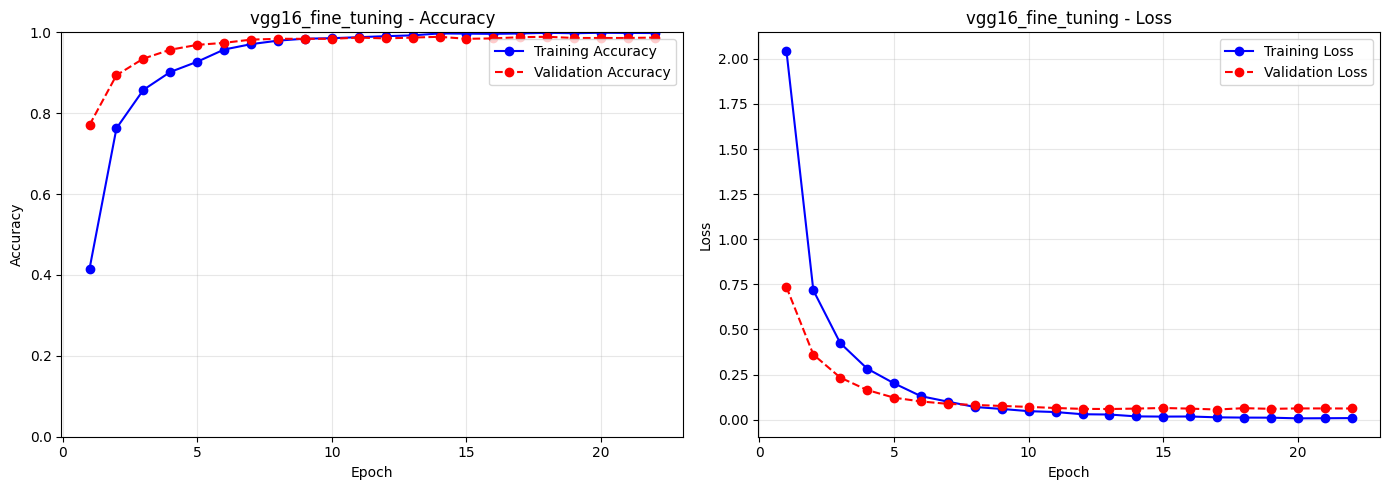

  1/250 ━━━━━━━━━━━━━━━━━━━━ 3:00 724ms/step - accuracy: 0.9375 - loss: 0.3046

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 100ms/step - accuracy: 0.9255 - loss: 0.2739

vgg16_fine_tuning - Test Accuracy: 0.9264, Test Loss: 0.2631


In [ ]:
# Use a lower learning rate for fine-tuning
vgg16_ft_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

result_vgg16_ft = train_and_evaluate(
    vgg16_ft_model, 'vgg16_fine_tuning',
    train_dataset, val_dataset, test_dataset,
    epochs=EPOCHS_FT
)
results.append(result_vgg16_ft)

**Observations (VGG16 Fine-Tuning):**

- **Test accuracy: 92.64%** — surprisingly **lower** than VGG16 feature extraction (93.98%), a drop of ~1.3%.
- This counter-intuitive result highlights VGG16's fragility under fine-tuning: its purely sequential architecture lacks skip connections, so when the top layers (`block5_conv1` onward) shift during training, the error propagates straight through all layers, potentially corrupting previously useful features.
- A very low learning rate (1e-5) was used to mitigate this, but even with careful tuning, VGG16 remains more prone to fine-tuning degradation compared to modern architectures with residual connections.
- This contrasts sharply with ResNet50, MobileNetV2, and EfficientNet, where fine-tuning consistently improved accuracy — confirming that skip connections act as a safeguard against catastrophic forgetting.

### 4.2 ResNet50 - Fine-Tuning

In [ ]:
def build_resnet50_fine_tuning(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES,
                               num_layers_to_unfreeze=20):
    """ResNet50 with the last N layers unfrozen for fine-tuning."""
    
    base_model = applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Freeze all layers first, then unfreeze the last N
    base_model.trainable = True
    for layer in base_model.layers[:-num_layers_to_unfreeze]:
        layer.trainable = False
    
    # Count trainable layers
    trainable_count = sum(1 for l in base_model.layers if l.trainable)
    print(f"Trainable layers in base: {trainable_count}/{len(base_model.layers)}")
    
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = applications.resnet50.preprocess_input(x)
    x = base_model(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='resnet50_fine_tuning')
    return model

resnet50_ft_model = build_resnet50_fine_tuning()
resnet50_ft_model.summary()

Trainable layers in base: 20/175


Model: "resnet50_fine_tuning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_12[0… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_9          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_10         │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_11         │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_6 (Stack)     │ (None, 224, 224,  │          0 │ get_item_9[0][0], │
│                     │ 3)                │            │ get_item_10[0][0… │
│                     │                   │            │ get_item_11[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 224, 224,  │          0 │ stack_6[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_3[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 10)        │      2,570 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 9,458,442 (36.08 MB)

 Non-trainable params: 14,656,384 (55.91 MB)

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 217ms/step - accuracy: 0.9932 - loss: 0.0338 - val_accuracy: 0.9930 - val_loss: 0.0205 - learning_rate: 1.0000e-05
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 163ms/step - accuracy: 0.9967 - loss: 0.0192 - val_accuracy: 0.9920 - val_loss: 0.0199 - learning_rate: 1.0000e-05
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 166ms/step - accuracy: 0.9941 - loss: 0.0266 - val_accuracy: 0.9950 - val_loss: 0.0187 - learning_rate: 1.0000e-05
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 160ms/step - accuracy: 0.9924 - loss: 0.0264 - val_accuracy: 0.9930 - val_loss: 0.0191 - learning_rate: 1.0000e-05
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 152ms/step - accuracy: 0.9921 - loss: 0.0294 - val_accuracy: 0.9930 - val_loss: 0.0193 - learning_rate: 1.0000e-05
Epoch 6/30
101/125 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9934 - loss: 0.0225  
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 155ms/st

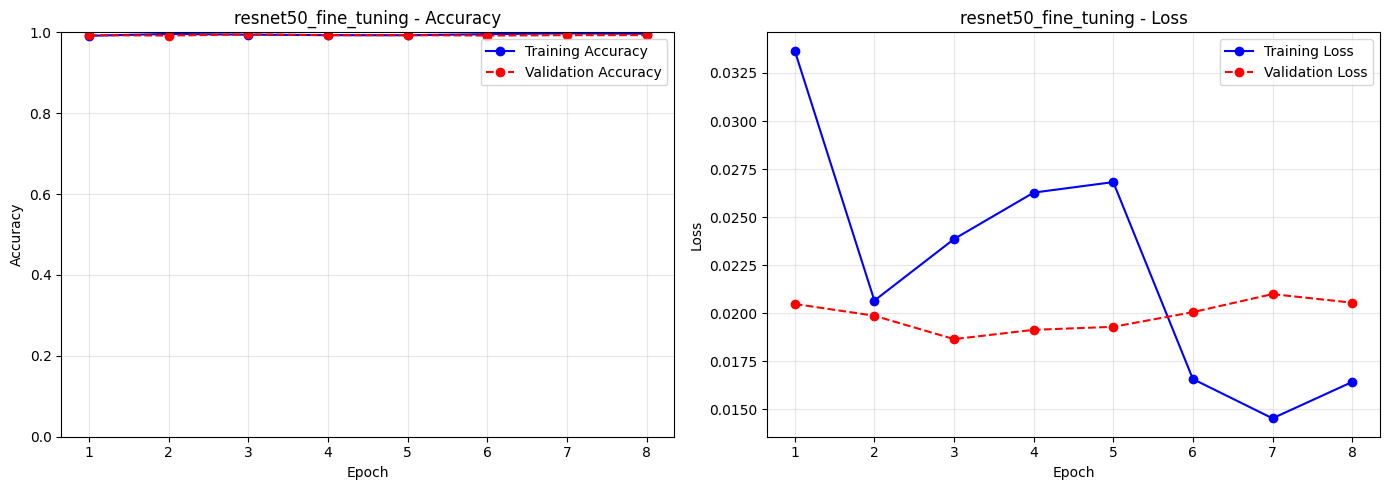

250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.9630 - loss: 0.1331

resnet50_fine_tuning - Test Accuracy: 0.9646, Test Loss: 0.1260


In [25]:
resnet50_ft_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

result_resnet50_ft = train_and_evaluate(
    resnet50_ft_model, 'resnet50_fine_tuning',
    train_dataset, val_dataset, test_dataset,
    epochs=EPOCHS_FT
)
results.append(result_resnet50_ft)

**Observations (ResNet50 Fine-Tuning):**

- **Test accuracy: 96.46%** — a modest +0.37% improvement over ResNet50 FE (96.09%).
- Fine-tuning the top 20 layers provided a small but consistent gain, confirming that adapting ResNet50's high-level features to STL-10-specific patterns is beneficial even when the frozen features were already excellent.
- ResNet50's skip connections make it robust to fine-tuning instability — the gradient can flow through the identity shortcuts, preventing catastrophic forgetting of lower-level features.
- The improvement is small because the FE baseline was already very high (96%); at this accuracy level, further gains require increasingly precise adaptation. A low learning rate (1e-5) ensured stability during the process.

### 4.3 MobileNetV2 - Fine-Tuning

In [26]:
def build_mobilenetv2_fine_tuning(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES,
                                  num_layers_to_unfreeze=30):
    """MobileNetV2 with the last N layers unfrozen for fine-tuning."""
    
    base_model = applications.MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    base_model.trainable = True
    for layer in base_model.layers[:-num_layers_to_unfreeze]:
        layer.trainable = False
    
    trainable_count = sum(1 for l in base_model.layers if l.trainable)
    print(f"Trainable layers in base: {trainable_count}/{len(base_model.layers)}")
    
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='mobilenetv2_fine_tuning')
    return model

mobilenet_ft_model = build_mobilenetv2_fine_tuning()
mobilenet_ft_model.summary()

Trainable layers in base: 30/154


Model: "mobilenetv2_fine_tuning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 1,856,906 (7.08 MB)

 Non-trainable params: 731,584 (2.79 MB)

Epoch 1/30


W0000 00:00:1774459044.978337     187 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459044.991362     187 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459044.997455     187 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459045.007335     187 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459045.013173     187 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459045.025561     187 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459045.027103     187 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459045.028670     187 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459045.030828     187 gp

  1/125 ━━━━━━━━━━━━━━━━━━━━ 13:12 6s/step - accuracy: 0.1250 - loss: 2.8455

W0000 00:00:1774459045.800709     181 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459045.815473     181 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459045.815868     181 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459045.816191     181 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459045.816501     181 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459045.816810     181 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459045.817144     181 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459045.817579     181 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459045.818206     181 gp

  3/125 ━━━━━━━━━━━━━━━━━━━━ 32s 265ms/step - accuracy: 0.1441 - loss: 2.7448

...

  4/125 ━━━━━━━━━━━━━━━━━━━━ 27s 231ms/step - accuracy: 0.1549 - loss: 2.6972

W0000 00:00:1774459046.580838     181 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459046.581468     181 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459046.582108     181 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459046.582687     181 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459046.583240     181 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459046.583838     181 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459046.584463     181 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459046.584910     181 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459046.585411     181 gp

  5/125 ━━━━━━━━━━━━━━━━━━━━ 48:38 24s/step - accuracy: 0.1577 - loss: 2.6787

W0000 00:00:1774459046.781798     180 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459046.782103     180 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459046.782484     180 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459046.782807     180 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459046.783132     180 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459046.783662     180 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459046.784254     180 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459046.784855     180 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774459046.785365     180 gp

125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 117ms/step - accuracy: 0.2242 - loss: 2.2742 - val_accuracy: 0.6780 - val_loss: 1.3131 - learning_rate: 1.0000e-05
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 129ms/step - accuracy: 0.6716 - loss: 1.2604 - val_accuracy: 0.9050 - val_loss: 0.6378 - learning_rate: 1.0000e-05
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - accuracy: 0.8045 - loss: 0.7729 - val_accuracy: 0.9270 - val_loss: 0.3636 - learning_rate: 1.0000e-05
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 114ms/step - accuracy: 0.8644 - loss: 0.5287 - val_accuracy: 0.9460 - val_loss: 0.2484 - learning_rate: 1.0000e-05
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 120ms/step - accuracy: 0.8802 - loss: 0.4304 - val_accuracy: 0.9570 - val_loss: 0.1850 - learning_rate: 1.0000e-05
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - accuracy: 0.9055 - loss: 0.3472 - val_accuracy: 0.9650 - val_loss: 0.1509 - learning_rate: 1.0000e-05
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - 

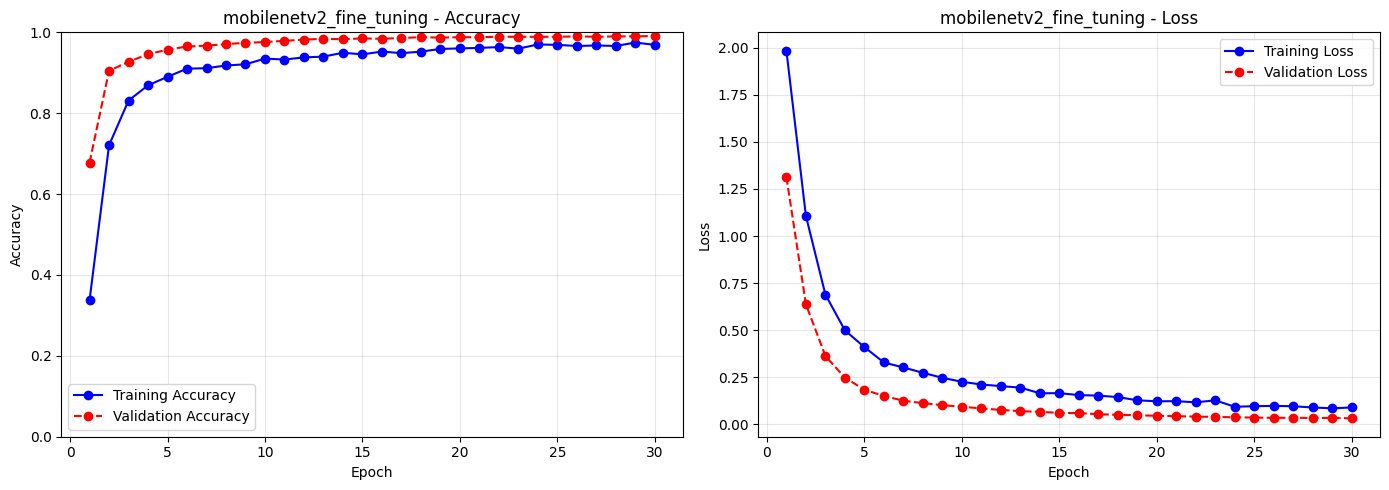

250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.9559 - loss: 0.1413 

mobilenetv2_fine_tuning - Test Accuracy: 0.9588, Test Loss: 0.1356


In [27]:
mobilenet_ft_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

result_mobilenet_ft = train_and_evaluate(
    mobilenet_ft_model, 'mobilenetv2_fine_tuning',
    train_dataset, val_dataset, test_dataset,
    epochs=EPOCHS_FT
)
results.append(result_mobilenet_ft)

**Observations (MobileNetV2 Fine-Tuning):**

- **Test accuracy: 95.88%** — +0.47% over MobileNetV2 FE (95.41%), a slightly larger gain than ResNet50's fine-tuning improvement.
- MobileNetV2 benefits more from fine-tuning because its lighter architecture has less representational capacity in its upper layers, so adapting those layers to STL-10-specific patterns extracts more task-relevant information.
- The model remains extremely parameter-efficient even with fine-tuning, keeping its advantage over VGG16/ResNet50 in model size while closing the accuracy gap with ResNet50 FT (96.46% vs. 95.88%).
- Fine-tuning MobileNetV2 is stable thanks to its inverted residual blocks with skip connections, which protect the lower-level features from being overwritten during backpropagation.

### 4.4 EfficientNetV2B0 - Fine-Tuning

In [ ]:
base_model.trainable = True

# Keep the bottom layers frozen, unfreeze the top 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# base_model.summary()

Model: "efficientnetv2-b0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_7[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 5,919,312 (22.58 MB)

 Trainable params: 1,163,872 (4.44 MB)

 Non-trainable params: 4,755,440 (18.14 MB)

Epoch 1/30


2026-03-25 17:25:32.638508: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1026] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnet_pipeline_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 138ms/step - accuracy: 0.9659 - loss: 0.1097 - val_accuracy: 0.9940 - val_loss: 0.0403 - learning_rate: 1.0000e-05
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 124ms/step - accuracy: 0.9741 - loss: 0.0977 - val_accuracy: 0.9940 - val_loss: 0.0384 - learning_rate: 1.0000e-05
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s -668987us/step - accuracy: 0.9747 - loss: 0.0883 - val_accuracy: 0.9950 - val_loss: 0.0355 - learning_rate: 1.0000e-05
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 145ms/step - accuracy: 0.9742 - loss: 0.0947 - val_accuracy: 0.9950 - val_loss: 0.0354 - learning_rate: 1.0000e-05
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 189ms/step - accuracy: 0.9719 - loss: 0.0846 - val_accuracy: 0.9950 - val_loss: 0.0351 - learning_rate: 1.0000e-05
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 193ms/step - accuracy: 0.9751 - loss: 0.0857 - val_accuracy: 0.9950 - val_loss: 0.0335 - learning_rate: 1.0000e-05
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/ste

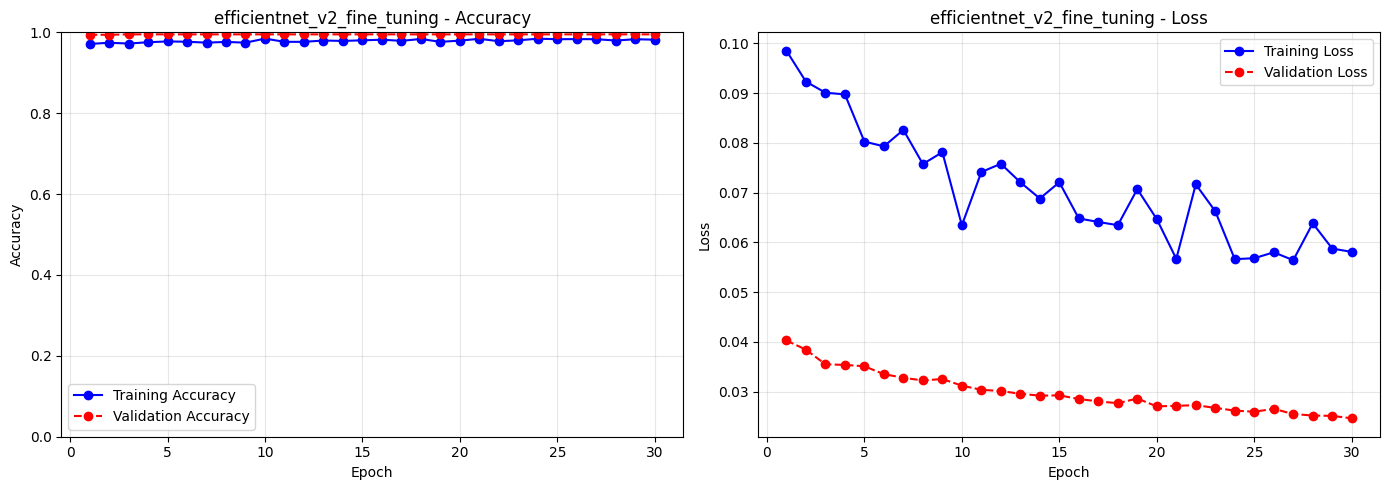

250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.9757 - loss: 0.0784

efficientnet_v2_fine_tuning - Test Accuracy: 0.9795, Test Loss: 0.0678


In [29]:
effnet_model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

result_effnet_ft = train_and_evaluate(
    effnet_model, 'efficientnet_v2_fine_tuning',
    train_dataset, val_dataset, test_dataset,
    epochs=EPOCHS_FT
)
results.append(result_effnet_ft)

**Observations (EfficientNetV2B0 Fine-Tuning):**

- **Test accuracy: 97.95%** — the **best overall model** across both notebooks, a marginal +0.10% over EfficientNet FE (97.85%).
- The small gain is expected: the frozen features were already near-optimal, so unfreezing the top 30 layers provided only minimal task-specific refinement.
- Fine-tuning was stable thanks to a very low learning rate (1e-5) and AdamW with weight decay (1e-4), which prevented catastrophic forgetting of the pretrained representations.
- EfficientNetV2B0 confirms the trend: modern architectures with residual-style connections (MBConv blocks) benefit from fine-tuning without the instability seen in VGG16.

---
## 5. Results Comparison

Summary of all pretrained models and strategies.

In [11]:
import pandas as pd

comparison_df = pd.DataFrame([
    {
        'Model': r['model_name'],
        'Test Accuracy': f"{r['test_accuracy']:.4f}",
        'Test Loss': f"{r['test_loss']:.4f}"
    }
    for r in results
])

print("\n" + "="*60)
print("RESULTS SUMMARY - Pretrained CNNs")
print("="*60)
display(comparison_df)

NameError: name 'results' is not defined

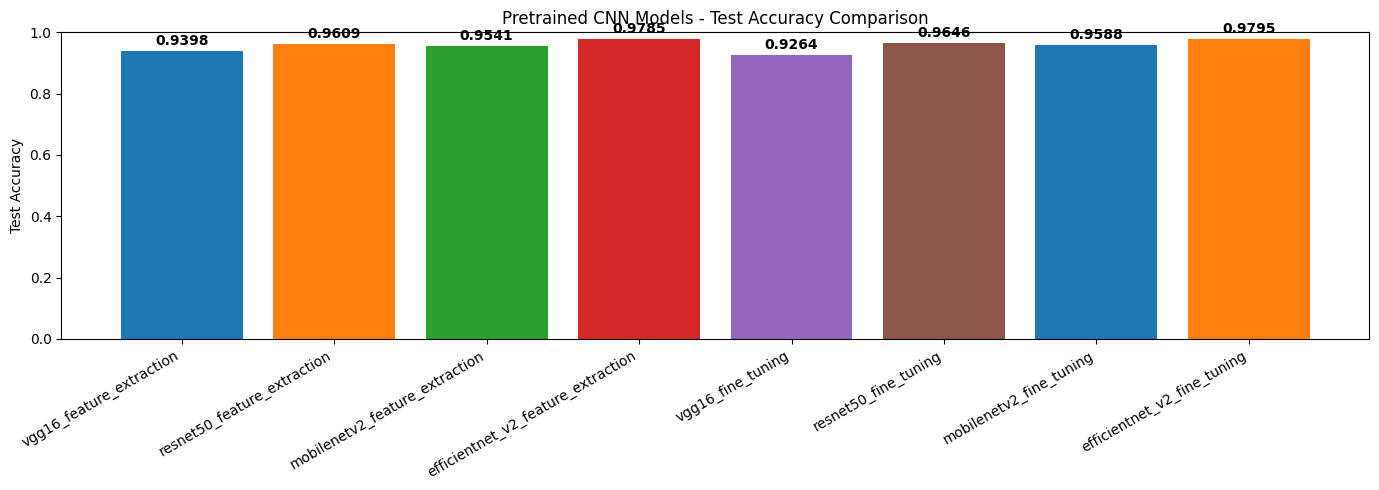

In [31]:
# Bar chart comparison
model_names = [r['model_name'] for r in results]
test_accs = [r['test_accuracy'] for r in results]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

plt.figure(figsize=(14, 5))
bars = plt.bar(range(len(model_names)), test_accs, color=colors[:len(model_names)])
plt.xticks(range(len(model_names)), model_names, rotation=30, ha='right')
plt.ylabel('Test Accuracy')
plt.title('Pretrained CNN Models - Test Accuracy Comparison')
plt.ylim(0, 1)
for bar, acc in zip(bars, test_accs):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Comparison with Custom CNNs

Load the results from Part 1 (custom CNNs) and compare with the pretrained models. Custom model accuracies were obtained from Notebook 1 training runs.

In [ ]:
# Results from Part 1 (Custom CNNs notebook)
custom_results = [
    {'model_name': 'baseline_a_2blocks', 'test_accuracy': 0.5244, 'test_loss': 1.80},
    {'model_name': 'baseline_b_3blocks', 'test_accuracy': 0.5740, 'test_loss': 1.70},
    {'model_name': 'baseline_c_4blocks', 'test_accuracy': 0.5709, 'test_loss': 1.69},
    {'model_name': 'baseline_d_double_conv', 'test_accuracy': 0.4927, 'test_loss': 1.95},
    {'model_name': 'improved_cnn', 'test_accuracy': 0.6965, 'test_loss': 0.93},
    {'model_name': 'custom_resnet', 'test_accuracy': 0.5805, 'test_loss': 1.35},
    {'model_name': 'custom_inception', 'test_accuracy': 0.6709, 'test_loss': 1.02},
]

all_results = custom_results + results

all_df = pd.DataFrame([
    {
        'Model': r['model_name'],
        'Type': 'Custom' if r in custom_results else 'Pretrained',
        'Test Accuracy': f"{r['test_accuracy']:.4f}",
        'Test Loss': f"{r['test_loss']:.4f}"
    }
    for r in all_results
])

print("\n" + "="*70)
print("FULL RESULTS SUMMARY - Custom vs Pretrained CNNs")
print("="*70)
display(all_df)

NameError: name 'pd' is not defined

In [2]:
# Combined bar chart
all_names = [r['model_name'] for r in all_results]
all_accs = [r['test_accuracy'] for r in all_results]
all_colors = ['steelblue' if r in custom_results else 'coral' for r in all_results]

plt.figure(figsize=(16, 6))
bars = plt.bar(range(len(all_names)), all_accs, color=all_colors)
plt.xticks(range(len(all_names)), all_names, rotation=40, ha='right')
plt.ylabel('Test Accuracy')
plt.title('All Models - Test Accuracy Comparison (Blue=Custom, Red=Pretrained)')
plt.ylim(0, 1)
for bar, acc in zip(bars, all_accs):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=8)
plt.tight_layout()
plt.show()

NameError: name 'all_results' is not defined

---
## 7. Conclusions

**Best overall model: EfficientNetV2B0 Fine-Tuning (97.95%)**, closely followed by EfficientNetV2B0 Feature Extraction (97.85%). This confirms that EfficientNet's compound scaling and modern architecture design provide superior transfer learning representations.

**Feature Extraction vs. Fine-Tuning:**

| Model | FE Accuracy | FT Accuracy | Δ |
|-------|------------|------------|---|
| VGG16 | 93.98% | 92.64% | -1.34% |
| ResNet50 | 96.09% | 96.46% | +0.37% |
| MobileNetV2 | 95.41% | 95.88% | +0.47% |
| EfficientNetV2B0 | 97.85% | 97.95% | +0.10% |

Fine-tuning improved ResNet50, MobileNetV2, and EfficientNet modestly, but **hurt VGG16** — the only architecture without skip connections. This pattern strongly suggests that residual/shortcut connections act as a safeguard against catastrophic forgetting during fine-tuning, making modern architectures inherently more suitable for this strategy.

**Transfer learning vs. training from scratch:** The gap is dramatic — the worst pretrained model (VGG16 FT, 92.64%) still outperforms the best custom CNN (Improved CNN, 69.65%) by **+23 pp**. On small datasets like STL-10 (~4,000 training images), pretrained ImageNet features provide a massive advantage that no amount of architectural design from scratch can compensate for.

**Architecture ranking:**
1. **EfficientNetV2B0** — Best accuracy (97.95%), modern compound-scaled design with MBConv blocks and squeeze-and-excitation attention
2. **ResNet50** — Strong runner-up (96.46%), robust to fine-tuning thanks to skip connections
3. **MobileNetV2** — Excellent efficiency-accuracy tradeoff (95.88% with ~10× fewer parameters than ResNet50)
4. **VGG16** — Solid feature extractor (93.98%) but aging architecture; fine-tuning degrades performance due to lack of skip connections

**Practical considerations:** MobileNetV2 offers the best cost-benefit ratio for deployment requiring low latency or small model size. EfficientNetV2B0 is the best choice when accuracy is the primary concern. All four architectures dramatically outperform custom CNNs, confirming that transfer learning is essential when training data is limited.

**Potential improvements:** More aggressive fine-tuning schedules (unfreezing layers progressively in stages), stronger data augmentation, learning rate warmup, and ensemble methods could push accuracy beyond 98%.